In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_score, recall_score
import numpy as np

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ",device)

Using device:  cuda


In [10]:
import torch
device = torch.device("cuda:6")   # V100 with most free memory
print(device)
print(torch.cuda.get_device_name(6))

cuda:6
Tesla V100-PCIE-32GB


In [11]:
# -----------------------------
# Imports
# -----------------------------
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# -----------------------------
# Data Augmentation (ResNet paper style)
# -----------------------------
# Paper:
# - pad 4 pixels on each side
# - random 32x32 crop
# - random horizontal flip
# - normalize
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

# Testing: only normalize original image
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

# -----------------------------
# Load CIFAR-10
# -----------------------------
full_trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# -----------------------------
# Data Preparation (Exact paper augmentation)
# -----------------------------
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(full_trainset, [train_size, val_size])

# validation should use test transform (single-view)
val_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(testset, batch_size=128, shuffle=False)
print("Train samples :", len(train_dataset))
print("Val samples   :", len(val_dataset))
print("Test samples  :", len(testset))

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train samples : 45000
Val samples   : 5000
Test samples  : 10000


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# Basic Residual Block
# -----------------------------
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride,
            padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1,
            padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


# -----------------------------
# ResNet-32 for CIFAR-10
# -----------------------------
class ResNet32(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet32, self).__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(
            3, 16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)

        # n = 5
        self.layer1 = self._make_layer(16, 5, stride=1)
        self.layer2 = self._make_layer(32, 5, stride=2)
        self.layer3 = self._make_layer(64, 5, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = []

        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [13]:
model = ResNet32().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"In Millions          : {total_params/1e6:.3f} M")

Total Parameters     : 466,906
Trainable Parameters : 466,906
In Millions          : 0.467 M


In [14]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [15]:
# -----------------------------
# Training Setup (Exact paper hyperparameters)
# -----------------------------
model = ResNet32().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

# Paper schedule: drop LR at 32k and 48k iterations
# Approximate with epochs for CIFAR-10:
# 45k / 128 ≈ 352 iterations per epoch
# 32k ≈ 91 epochs, 48k ≈ 136 epochs, stop ≈ 182 epochs
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[91, 136],
    gamma=0.1
)

num_epochs = 182
import pandas as pd

# Store history
history = {
    "Epoch": [],
    "Train Loss": [],
    "Train Accuracy": [],
    "Validation Loss": [],
    "Validation Accuracy": [],
    "Learning Rate": []
}

# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            _, predicted = outputs.max(1)

            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return total_loss / len(loader), 100 * correct / total


# -----------------------------
# Training Function
# -----------------------------
def train_epoch():
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)

        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return total_loss / len(train_loader), 100 * correct / total


# -----------------------------
# Training Loop
# -----------------------------
num_epochs = 182

for epoch in range(1, num_epochs + 1):

    train_loss, train_acc = train_epoch()
    val_loss, val_acc = evaluate(val_loader)

    current_lr = optimizer.param_groups[0]['lr']

    scheduler.step()

    # Save values
    history["Epoch"].append(epoch)
    history["Train Loss"].append(train_loss)
    history["Train Accuracy"].append(train_acc)
    history["Validation Loss"].append(val_loss)
    history["Validation Accuracy"].append(val_acc)
    history["Learning Rate"].append(current_lr)

    # Print values
    print(
        f"Epoch {epoch:3d}/{num_epochs} | "
        f"LR: {current_lr:.4f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

# -----------------------------
# Save to Excel
# -----------------------------
df = pd.DataFrame(history)

excel_file = "resnet20_cifar10_training_results.xlsx"
df.to_excel(excel_file, index=False)

print(f"Results saved to: {excel_file}")

Epoch   1/182 | LR: 0.1000 | Train Loss: 1.6654 | Train Acc: 37.46% | Val Loss: 1.6780 | Val Acc: 39.34%
Epoch   2/182 | LR: 0.1000 | Train Loss: 1.1857 | Train Acc: 56.78% | Val Loss: 1.1590 | Val Acc: 59.32%
Epoch   3/182 | LR: 0.1000 | Train Loss: 0.9199 | Train Acc: 67.44% | Val Loss: 0.9968 | Val Acc: 65.60%
Epoch   4/182 | LR: 0.1000 | Train Loss: 0.7621 | Train Acc: 73.10% | Val Loss: 0.7947 | Val Acc: 71.54%
Epoch   5/182 | LR: 0.1000 | Train Loss: 0.6431 | Train Acc: 77.38% | Val Loss: 0.9772 | Val Acc: 67.38%
Epoch   6/182 | LR: 0.1000 | Train Loss: 0.5685 | Train Acc: 80.09% | Val Loss: 0.9607 | Val Acc: 69.04%
Epoch   7/182 | LR: 0.1000 | Train Loss: 0.5010 | Train Acc: 82.53% | Val Loss: 0.7529 | Val Acc: 74.90%
Epoch   8/182 | LR: 0.1000 | Train Loss: 0.4513 | Train Acc: 84.35% | Val Loss: 0.6820 | Val Acc: 76.60%
Epoch   9/182 | LR: 0.1000 | Train Loss: 0.4080 | Train Acc: 85.68% | Val Loss: 0.6682 | Val Acc: 76.88%
Epoch  10/182 | LR: 0.1000 | Train Loss: 0.3682 | Train

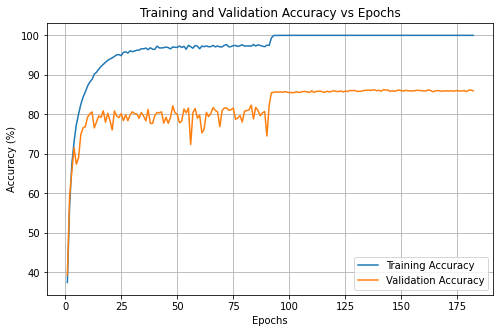

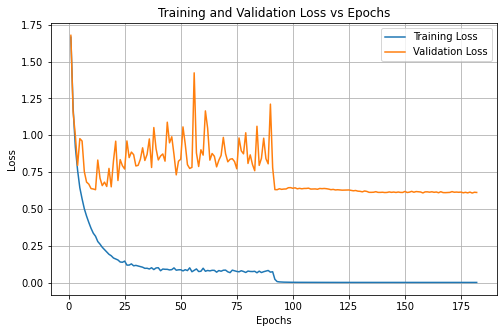

In [16]:
import matplotlib.pyplot as plt

epochs = history["Epoch"]

# ---------------- Accuracy Curve ----------------
plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Accuracy"], label="Training Accuracy")
plt.plot(epochs, history["Validation Accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

# ---------------- Loss Curve ----------------
plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Loss"], label="Training Loss")
plt.plot(epochs, history["Validation Loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# -----------------------------
# Final Test Evaluation
# -----------------------------
test_loss, test_acc = evaluate(test_loader)

# Precision & Recall
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

precision = precision_score(all_targets, all_preds, average='macro')
recall = recall_score(all_targets, all_preds, average='macro')

print("\n===== Final Test Metrics =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Precision (Macro): {precision:.4f}")
print(f"Test Recall (Macro): {recall:.4f}")



===== Final Test Metrics =====
Test Loss: 0.6282
Test Accuracy: 85.80%
Test Precision (Macro): 0.8573
Test Recall (Macro): 0.8580
